### Import Libraries

In [12]:
# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
import itertools

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# Statistics.
import scipy.stats as stats

# Data frames.
import pandas as pd

# Statistical plots.
import seaborn as sns

from scipy.stats import norm

### Task 1: Permutations and Combinations

In [13]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with milk in first.
no_cups_milk_first = 6

# Number of cups of tea with tea in first.
no_cups_tea_first = 6

In [14]:
# Number of ways of selecting four cups from eight.
ways = math.comb(no_cups, no_cups_milk_first)

# Show.
ways

924

### Task 2: numpy's Normal Distribution

In [15]:
sample = np.random.normal(10, 3, 100000)

In [16]:
stats.shapiro(sample)

ShapiroResult(statistic=0.9999787211418152, pvalue=0.8859312534332275)

(array([4.8000e+01, 6.0100e+02, 4.3170e+03, 1.6250e+04, 3.0288e+04,
        2.9446e+04, 1.4718e+04, 3.7960e+03, 5.0800e+02, 2.8000e+01]),
 array([-2.47891816,  0.03915983,  2.55723783,  5.07531582,  7.59339381,
        10.1114718 , 12.6295498 , 15.14762779, 17.66570578, 20.18378378,
        22.70186177]),
 <BarContainer object of 10 artists>)

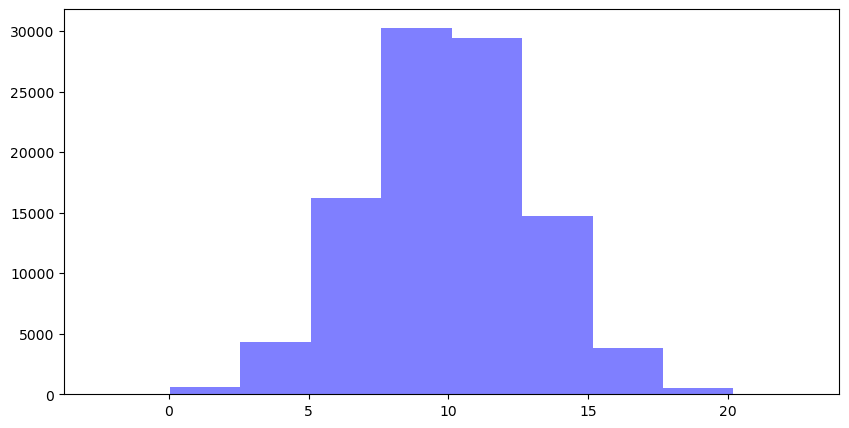

In [17]:
# Create an empty data frame.
fig, ax = plt.subplots(figsize=(10, 5))

# Create histogram.
ax.hist(sample, color='blue', alpha=0.5, label='Sample')

(array([4.96410359e-05, 1.48923108e-04, 4.86482152e-04, 1.63815418e-03,
        4.12020598e-03, 9.01481212e-03, 1.86551013e-02, 3.49472893e-02,
        5.77126683e-02, 8.38635660e-02, 1.07631694e-01, 1.27746242e-01,
        1.30774345e-01, 1.24152231e-01, 1.02747016e-01, 7.74995852e-02,
        5.11004823e-02, 3.12837808e-02, 1.62822598e-02, 7.64471953e-03,
        3.52451355e-03, 1.22116948e-03, 4.16984701e-04, 1.09210279e-04,
        4.96410359e-05]),
 array([-2.47891816, -1.47168696, -0.46445576,  0.54277543,  1.55000663,
         2.55723783,  3.56446902,  4.57170022,  5.57893142,  6.58616261,
         7.59339381,  8.60062501,  9.60785621, 10.6150874 , 11.6223186 ,
        12.6295498 , 13.63678099, 14.64401219, 15.65124339, 16.65847459,
        17.66570578, 18.67293698, 19.68016818, 20.68739937, 21.69463057,
        22.70186177]),
 <BarContainer object of 25 artists>)

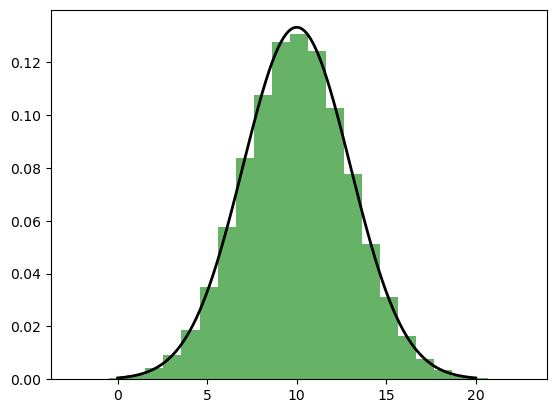

In [18]:
mu, std = norm.fit(sample)
x = np.linspace(0, 20, 1001)
p = norm.pdf(x, mu, std)
fig, ax = plt.subplots(1, 1) 
plt.plot(x, p, 'k', linewidth=2)
#ax.hist(sample, color='blue', alpha=0.5, label='Sample')
plt.hist(sample, bins=25, density=True, alpha=0.6, color='g')

### Task 3: t-Test Calculation

In [19]:
Before = [63,68,70,64,74,67,70,57,66,65]

In [20]:
After = [64,64,68,64,73,70,72,54,61,63]

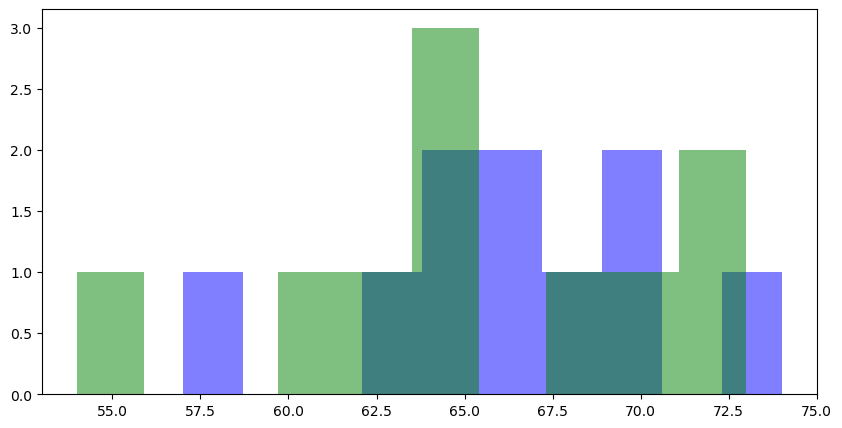

In [21]:
# Create an empty data frame.
fig, ax = plt.subplots(figsize=(10, 5))

# Create histogram.
ax.hist(Before, color='blue', alpha=0.5, label='Before')

# Create histogram.
ax.hist(After, color='green', alpha=0.5, label='After');

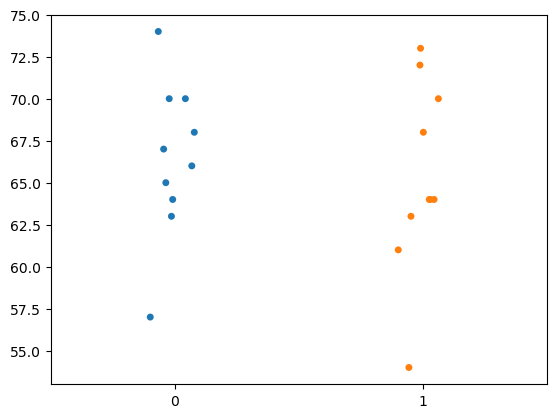

In [22]:
# Create a strip plot.
sns.stripplot(data=[Before, After]);

In [23]:
stats.ttest_ind(Before, After)

Ttest_indResult(statistic=0.4740968275126808, pvalue=0.6411310132871086)

In [24]:
stats.ttest_rel(Before, After)

Ttest_relResult(statistic=1.337227482480628, pvalue=0.21396011317404623)

### Task 4: ANOVA

In [25]:
no_type_ii = 0

In [26]:
# First sample.
sample_a = np.random.normal(loc=4.9, scale=0.1, size=100)

# Second sample.
sample_b = np.random.normal(loc=5.0, scale=0.1, size=100)

# Third sample.
sample_c = np.random.normal(loc=5.1, scale=0.1, size=100)

In [27]:
# Create data frame.
df = pd.DataFrame({'Sample_a': sample_a, 'Sample_b': sample_b, 'Sample_c': sample_c})

# Show.
df

,Sample_a,Sample_b,Sample_c
0,4.971129,4.887779,5.134682
1,5.006810,5.033585,5.020740
2,4.847719,4.938815,4.987877
3,4.949098,5.019514,5.137775
4,4.913643,5.018150,5.125048
...,...,...,...
95,4.936845,5.027313,5.028160
96,5.014068,5.082987,5.011427
97,4.648123,5.082165,5.201949
98,4.979530,5.027599,5.079247


In [28]:
# Perform ANOVA.
f_statistic, p_value = stats.f_oneway(df['Sample_a'], df['Sample_b'], df['Sample_c'])

# Show.
f_statistic, p_value

(100.31270952982885, 5.179682149204791e-34)

In [29]:
# Tukey's HSD.
res = stats.tukey_hsd(df['Sample_a'], df['Sample_b'], df['Sample_c'])

# Show.
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.104     0.000    -0.137    -0.071
 (0 - 2)     -0.201     0.000    -0.234    -0.167
 (1 - 0)      0.104     0.000     0.071     0.137
 (1 - 2)     -0.097     0.000    -0.130    -0.063
 (2 - 0)      0.201     0.000     0.167     0.234
 (2 - 1)      0.097     0.000     0.063     0.130



In [30]:
#https://researchdatapod.com/type-ii-error-calculator/
import math
from scipy.stats import norm

def calculate_type_ii_error(n, alpha, d, sigma, test_type="two-tailed"):
    """
    Calculate Type II Error (β) for a given sample size, significance level, effect size, and standard deviation.

    Parameters:
        n (int): Sample size
        alpha (float): Significance level
        d (float): Effect size
        sigma (float): Standard deviation
        test_type (str): "one-tailed" or "two-tailed" test

    Returns:
        float: Type II Error (β)
    """
    if test_type == "two-tailed":
        alpha /= 2

    # Calculate Z-scores
    z_alpha = norm.ppf(1 - alpha)  # Critical Z for alpha
    z_power = (math.sqrt(n) * d / sigma) - z_alpha

    # Calculate Type II Error (β)
    beta = norm.cdf(z_power)
    if beta < 0.2:
        return True 
    else: 
        return False

# Example usage
n = 50
alpha = 0.05
d = 0.5
sigma = 1.0
test_type = "two-tailed"

beta = calculate_type_ii_error(n, alpha, d, sigma, test_type)
print(f"Type II Error (β): {beta:.5f}")
interpretation = "High β indicates low statistical power." 


Type II Error (β): 0.00000


In [31]:
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if calculate_type_ii_error(n, alpha, d, sigma) == True:
        # Increment the number of rejections.
        no_type_ii += 1

# Show the number of rejections.
no_type_ii

0